# 1. Text normalization
- split into sentences
- split into tokens
- normalize (stemming or lemmatization)
- create vocalubrary

# Main errors
- nltk downloads well but path at my PC is always wrong so I choose to try spacy

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ксения\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
# Sentence Tokenization
sentences = sent_tokenize(text)
print("Sentence Tokenization:")
for idx, sentence in enumerate(sentences[0:10]):
    print(f"{idx+1}: {sentence}")

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\Ксения/nltk_data'
    - 'c:\\Users\\Anaconda3\\envs\\nlp_env\\nltk_data'
    - 'c:\\Users\\Anaconda3\\envs\\nlp_env\\share\\nltk_data'
    - 'c:\\Users\\Anaconda3\\envs\\nlp_env\\lib\\nltk_data'
    - 'C:\\Users\\Ксения\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [6]:
import os # Operating System - for work with files and folders
import spacy
from spacy.language import Language
from spacy.tokens import Doc
import re
from collections import Counter
from spacy.lang.en.stop_words import STOP_WORDS
import matplotlib.pyplot as plt

In [7]:
nlp = spacy.load("en_core_web_sm") # download model, pre-traind small model in English

About data: it's the book I reading now called "**Anne from green Gables**" - consist 38 chapter. I am currently reading the book 'Anne from Green Gables' with my English language club, and I am on the fifth chapter.  This data is on my google drive and previously I delete all "chapter NN" and titles of chapter, and credits of the book.

In [4]:
base_path = os.getcwd() # current working directory
file_path = os.path.join(base_path, "..", "data", "without_chap_and_title", "eng_Anne_of_green_gables.txt")

# converts the relative path into an absolute path, which is the full path
file_path = os.path.abspath(file_path)

text = open(file_path, encoding="utf-8").read()
print(text[0:500])

Mrs. Rachel Lynde lived just where the Avonlea main road dipped down
into a little hollow, fringed with alders and ladies' eardrops and
traversed by a brook that had its source away back in the woods of the
old Cuthbert place; it was reputed to be an intricate, headlong brook
in its earlier course through those woods, with dark secrets of pool
and cascade; but by the time it reached Lynde's Hollow it was a quiet,
well-conducted little stream, for not even a brook could run past Mrs.
Rachel Lynd


In [4]:
print(f"Text length: {len(text)}")

Text length: 558212


## Sentences

In my text there are the forms of Miss, Mr, Doctor and Mrs. They end with a dot that can be considered as a sentence, but it is not valid, so let’s write the function after which will replace all abbreviations with complete forms of words.

Therefore we will use the **preprocess_text** function usually designed to replace abbreviations (such as "Mr.", "Ms.", "Dr." etc) with full forms (for example, "Mr" -> "Mister", "Ms." -> "Miss"). This is important because abbreviations can be misinterpreted in the process of tokenization and text analysis.

In [5]:
abbreviations = {
    "Mr.": "Mister",
    "Mrs.": "Mistress",
    "Ms.": "Miss",
    "Dr.": "Doctor",
    "Prof.": "Professor",
    "Sr.": "Senior",
    "Jr.": "Junior"
}

In [6]:
# function for preprocessing text from capital letters and abbreviations
def preprocess_text(text):
    # replace the abbreviations with full forms
    for abbr, full_version in abbreviations.items():
        text = text.replace(abbr, full_version)  # use substitution in the text
    return text.lower()

In [7]:
# pre-treat
text = preprocess_text(text)

In [ ]:
# add a component for splitting sentences
if "sentencizer" not in nlp.pipe_names: # сheck if we used this method earlier, if we don’t plug in 
    nlp.add_pipe("sentencizer") # use regex inside to split text to sentences

# pass to spacy model
doc = nlp(text) # class of spacy. 

# patisse on the sentence
sentences = [sent.text.strip() for sent in doc.sents] # doc.sents - generator of all sentences in the text

In [9]:
# outpute
print("Sentence Tokenization:")
for idx, sentence in enumerate(sentences[:5]):
    print(f"{idx+1}: {sentence}")

Sentence Tokenization:
1: ﻿mistress rachel lynde lived just where the avonlea main road dipped down
into a little hollow, fringed with alders and ladies' eardrops and
traversed by a brook that had its source away back in the woods of the
old cuthbert place; it was reputed to be an intricate, headlong brook
in its earlier course through those woods, with dark secrets of pool
and cascade; but by the time it reached lynde's hollow it was a quiet,
well-conducted little stream, for not even a brook could run past mistress
rachel lynde's door without due regard for decency and decorum; it
probably was conscious that mistress rachel was sitting at her window,
keeping a sharp eye on everything that passed, from brooks and
children up, and that if she noticed anything odd or out of place she
would never rest until she had ferreted out the whys and wherefores
thereof.
2: there are plenty of people, in avonlea and out of it, who can attend
closely to their neighbours' business by dint of neglecti

## Split into tokens


- errors -- \ufeff /.\n#@--- symbols in beginning of rows  

In [10]:
def tokenize_sentences(sentences):
    tokenized_sentences = []
    for idx, sentence in enumerate(sentences):
        sentence = sentence.lstrip('\ufeff') # remove the BOM symbol (if any) at the beginning of the line        # Токенизация предложения
        sent_doc = nlp(sentence)  #  process the proposal for tokenization
        # select only words, excluding unwanted characters ,/.\n#@
        tokens = [token.text for token in sent_doc if token.text.strip()]
        tokenized_sentences.append(tokens)
        # we write toks for each sentence
        print(f"Sentence {idx + 1} Words: {tokens}")
    return tokenized_sentences

# apply tokenization to proposals
tokenized_sentences = tokenize_sentences(sentences)

Выходные данные были обрезаны до нескольких последних строк (5000).
Sentence 1397 Words: ['and', 'i', "'ll", 'have', 'to', 'give', 'her', 'a', 'talking', 'to', 'about', 'it', '.']
Sentence 1398 Words: ['but', 'we', 'must', 'make', 'allowances', 'for', 'her', '.']
Sentence 1399 Words: ['she', "'s", 'never', 'been', 'taught', 'what', 'is', 'right', '.']
Sentence 1400 Words: ['and', 'you', '_', 'were', '_', 'too', 'hard', 'on', 'her', ',', 'rachel', '.']
Sentence 1401 Words: ['"', 'marilla', 'could', 'not', 'help', 'tacking', 'on', 'that', 'last', 'sentence', ',', 'although', 'she', 'was', 'again', 'surprised', 'at', 'herself', 'for', 'doing', 'it', '.']
Sentence 1402 Words: ['mistress', 'rachel', 'got', 'up', 'with', 'an', 'air', 'of', 'offended', 'dignity', '.']
Sentence 1403 Words: ['"', 'well', ',', 'i', 'see', 'that', 'i', "'ll", 'have', 'to', 'be', 'very', 'careful', 'what', 'i', 'say', 'after', 'this', ',', 'marilla', ',', 'since', 'the', 'fine', 'feelings', 'of', 'orphans', ',', '

# Normalization

There are two ways lemmatization or stematization. The goal of both stemming and lemmatization is to reduce inflectional forms and sometimes derivationally related forms of a word to a common base form. BUT:
- __lemarization__ - generally defines stemming as the process of stripping affixes from words to obtain stemmed word strings, and lemmatization as the larger enterprise of reducing morphological variants to one dictionary base form.
 happiness -> happy
 
- __stematization__ - chops off the ends of words in the hope of achieving this goal correctly most of the time, and often includes the removal of derivational affixes. (more rough)
 happiness -> happi  not happy
 running ->  run

In [ ]:
# function for normalizing the text with lemmatization and leading to lower case
def lemmatize_tokens(tokenized_sentences):
    lemmatized_sentences = []

    for sentence in tokenized_sentences:
        # apply lemmatization for each token and bring to lower case
        lemmatized_sentence = [nlp(word.lower())[0].lemma_ for word in sentence if word.strip()]  # .lemma_ - the function of a token in spaCy, which returns the lemma - the basic (dictionary) word form
        lemmatized_sentences.append(lemmatized_sentence)

    return lemmatized_sentences

In [12]:
# lemmatization of tokens
lemmatized_sentences = lemmatize_tokens(tokenized_sentences)

In [13]:
# lemmatization results
for idx, sentence in enumerate(lemmatized_sentences):
    print(f"Lemmatized Sentence {idx + 1}: {sentence}")

Lemmatized Sentence 1: ['mistress', 'rachel', 'lynde', 'live', 'just', 'where', 'the', 'avonlea', 'main', 'road', 'dip', 'down', 'into', 'a', 'little', 'hollow', ',', 'fringe', 'with', 'alder', 'and', 'lady', "'", 'eardrop', 'and', 'traverse', 'by', 'a', 'brook', 'that', 'have', 'its', 'source', 'away', 'back', 'in', 'the', 'wood', 'of', 'the', 'old', 'cuthbert', 'place', ';', 'it', 'be', 'repute', 'to', 'be', 'an', 'intricate', ',', 'headlong', 'brook', 'in', 'its', 'early', 'course', 'through', 'those', 'wood', ',', 'with', 'dark', 'secret', 'of', 'pool', 'and', 'cascade', ';', 'but', 'by', 'the', 'time', 'it', 'reach', 'lynde', "'s", 'hollow', 'it', 'be', 'a', 'quiet', ',', 'well', '-', 'conduct', 'little', 'stream', ',', 'for', 'not', 'even', 'a', 'brook', 'could', 'run', 'past', 'mistress', 'rachel', 'lynde', "'s", 'door', 'without', 'due', 'regard', 'for', 'decency', 'and', 'decorum', ';', 'it', 'probably', 'be', 'conscious', 'that', 'mistress', 'rachel', 'be', 'sit', 'at', 'she'

In [ ]:
def clean_tokens(sentences):
    cleaned_sentences = []
    for sentence in sentences:
        cleaned = [re.sub(r'[^a-z]', '', word) for word in sentence] #- clears word lists from anything that is not lowercase Latin, and removes empty tokens.
        # remove empty lines if the word has become empty
        cleaned = [word for word in cleaned if word]
        cleaned_sentences.append(cleaned)
    return cleaned_sentences

In [15]:
# get stop words from spaCy
spacy_stopwords = nlp.Defaults.stop_words

# see example of stop-words
print("Example of stop-words:")
print(sorted(list(spacy_stopwords))[:])

Example of stop-words:
["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'both', 'bottom', 'but', 'by', 'ca', 'call', 'can', 'cannot', 'could', 'did', 'do', 'does', 'doing', 'done', 'down', 'due', 'during', 'each', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'four', 'from', 'front', 'full', 'further', 'get', 'give', 'go', 'had', 'has', 'have', 'he', 'hen

In [16]:
# remove stop-words from lemmatized text
def remove_stopwords(lemmatized_sentences):
    filtered_sentences = []

    for sentence in lemmatized_sentences:
        filtered = [word for word in sentence if word not in spacy_stopwords]
        filtered_sentences.append(filtered)

    return filtered_sentences

filtered_sentences = remove_stopwords(lemmatized_sentences)
filtered_sentences = clean_tokens(filtered_sentences)

print("Sentences without stop-words:")
for idx, sentence in enumerate(filtered_sentences):
    print(f"Filtered Sentence {idx + 1}: {sentence}")

Sentences without stop-words:
Filtered Sentence 1: ['mistress', 'rachel', 'lynde', 'live', 'avonlea', 'main', 'road', 'dip', 'little', 'hollow', 'fringe', 'alder', 'lady', 'eardrop', 'traverse', 'brook', 'source', 'away', 'wood', 'old', 'cuthbert', 'place', 'repute', 'intricate', 'headlong', 'brook', 'early', 'course', 'wood', 'dark', 'secret', 'pool', 'cascade', 'time', 'reach', 'lynde', 'hollow', 'quiet', 'conduct', 'little', 'stream', 'brook', 'run', 'past', 'mistress', 'rachel', 'lynde', 'door', 'regard', 'decency', 'decorum', 'probably', 'conscious', 'mistress', 'rachel', 'sit', 'window', 'sharp', 'eye', 'pass', 'brooks', 'child', 'notice', 'odd', 'place', 'rest', 'ferret', 's', 'wherefore', 'thereof']
Filtered Sentence 2: ['plenty', 'people', 'avonlea', 'attend', 'closely', 'neighbour', 'business', 'dint', 'neglect', 'mistress', 'rachel', 'lynde', 'capable', 'creature', 'manage', 'concern', 'folk', 'bargain']
Filtered Sentence 3: ['notable', 'housewife', 'work', 'run', 'sew', 'ci

# Build dictionary

In [ ]:
# create a dictionary of word frequencies
vocabulary = {}

for sentence in filtered_sentences:
    for word in sentence:
        vocabulary[word] = vocabulary.get(word, 0) + 1 # how many times has this word been used

# output dictionary sorted by decreasing frequency
sorted_vocab = {k: v for k, v in sorted(vocabulary.items(), key=lambda x: x[1], reverse=True)} # make vocab and sorted by frequency

print("Vocabulary:")
for word, freq in list(sorted_vocab.items())[:]:
    print(f"{word}: {freq}")


Vocabulary:
anne: 1192
marilla: 842
think: 503
diana: 410
mistress: 404
know: 365
matthew: 358
come: 355
like: 335
look: 298
little: 295
oh: 275
girl: 274
thing: 259
tell: 253
good: 237
feel: 236
time: 216
eye: 171
school: 159
miss: 154
want: 150
lynde: 149
day: 146
home: 146
white: 144
night: 143
green: 136
child: 135
barry: 134
long: 133
mister: 133
sit: 131
gable: 125
right: 122
find: 119
hair: 116
old: 115
hand: 113
gilbert: 113
mean: 112
talk: 112
face: 109
imagine: 109
ask: 107
away: 106
way: 106
suppose: 105
head: 105
let: 103
hear: 98
heart: 97
year: 96
room: 96
red: 95
love: 95
jane: 95
dress: 94
avonlea: 93
people: 93
use: 91
pretty: 90
rachel: 89
life: 89
ruby: 87
big: 84
course: 83
mind: 83
cry: 83
evening: 81
try: 81
stay: 79
bring: 78
morning: 78
real: 77
boy: 77
word: 77
live: 76
glad: 76
leave: 75
allan: 75
believe: 74
josie: 73
place: 72
bed: 72
new: 72
sure: 71
grow: 71
friend: 70
house: 69
hard: 69
afternoon: 67
wood: 66
bad: 65
lovely: 65
cuthbert: 64
yes: 64
window

In [18]:
vocabulary["marilla"]

842

In [19]:
len(vocabulary.keys())

5292

# 2. BPE
- implement algithm
- sreate vocalubrary
- convert text into tokenz

BPE - splitting text into sub-phrases or subwords.
    ("u", "g") -> "ug"
    ("u", "n") -> "un"
    ("h", "ug") -> "hug"

In [8]:
from collections import defaultdict

In [9]:
# the same data but just saved without abbreviations like Mrs., but with full versions of words
base_path = os.getcwd() # current working directory
file_path = os.path.join(base_path, "..", "data", "without_chap_and_title", "eng_Anne_full_abbr.txt")

# converts the relative path into an absolute path, which is the full path
file_path = os.path.abspath(file_path)

text = open(file_path, encoding="utf-8").read()
print(text[0:500])

Mistress Rachel Lynde lived just where the Avonlea main road dipped down into a little hollow, fringed with alders and ladies' eardrops and traversed by a brook that had its source away back in the woods of the old Cuthbert place; it was reputed to be an intricate, headlong brook in its earlier course through those woods, with dark secrets of pool and cascade; but by the time it reached Lynde's Hollow it was a quiet, well-conducted little stream, for not even a brook could run past Mistress Rach


In [10]:
# delete everything except the letters and spaces, and make all text lowercase
text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)
print(text)

mistress rachel lynde lived just where the avonlea main road dipped down into a little hollow fringed with alders and ladies eardrops and traversed by a brook that had its source away back in the woods of the old cuthbert place it was reputed to be an intricate headlong brook in its earlier course through those woods with dark secrets of pool and cascade but by the time it reached lyndes hollow it was a quiet wellconducted little stream for not even a brook could run past mistress rachel lyndes door without due regard for decency and decorum it probably was conscious that mistress rachel was sitting at her window keeping a sharp eye on everything that passed from brooks and children up and that if she noticed anything odd or out of place she would never rest until she had ferreted out the whys and wherefores thereof there are plenty of people in avonlea and out of it who can attend closely to their neighbours business by dint of neglecting their own but mistress rachel lynde was one of

In [11]:
def get_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split() #  breaks the word into individual characters
        for i in range(len(symbols)-1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs # ex. ('e', 'r'): 2

def merge_vocab(pair, vocab): # ('l', 'o') and 'l o w': 5
    new_vocab = {}
    bigram = ' '.join(pair) # make 'l o'
    replacement = ''.join(pair) # 'lo'
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab # 'lo w': 5, 'lo w e r': 2

In [ ]:
# 10 was not enough - happ y yes</w>
def byte_pair_encoding(text, num_merges=100): # how many times the algorithm will merge the most common character pairs
    words = text.split() # words
    vocab = {}
    for word in words:
        chars = ' '.join(list(word)) + ' </w>' # 'l o w </w>'
        vocab[chars] = vocab.get(chars, 0) + 1 

    print("Initial vocabulary:")
    print(vocab)

    symbols = set() 
    # collect a set of all unique characters including </w> from the initial dictionary
    for word in vocab:
        symbols.update(word.split())

    print("Symbols set:", symbols)

    # merger of pairs
    merges = []
    for _ in range(num_merges):
        print("-" * 30)
        pairs = get_stats(vocab)
        print("Pairs:")
        print(pairs)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        print("Best pair:", best_pair)
        merges.append(best_pair)
        vocab = merge_vocab(best_pair, vocab) # replaces all entries of this pair in words with a sticky token 
        print("Updated vocabulary:")
        print(vocab)
        new_token = ''.join(best_pair) # creates a new token with no space between symbols
        symbols.add(new_token)

    # Build final vocabulary: token -> id
    final_vocab = {token: idx for idx, token in enumerate(sorted(symbols))}
    return merges, final_vocab

In [13]:
def apply_bpe(word, merges):
    word = list(word) + ['</w>'] # words become a list of characters
    while True:
        pairs = [(word[i], word[i+1]) for i in range(len(word)-1)] # current, next
        pair_ranks = {pair: idx for idx, pair in enumerate(merges)}
        ranked = [(pair, pair_ranks[pair]) for pair in pairs if pair in pair_ranks]
        if not ranked:
            break
        best_pair = min(ranked, key=lambda x: x[1])[0]
        new_word = []
        # combining a pair into a new word by syllables ('low', 'er' </w>)
        i = 0
        while i < len(word):
            if i < len(word)-1 and (word[i], word[i+1]) == best_pair:
                new_word.append(word[i] + word[i+1])
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        word = new_word
    return word

In [25]:
# applying BPE to text
merges, vocab = byte_pair_encoding(text, num_merges=5000)

Выходные данные были обрезаны до нескольких последних строк (5000).
 'hanged</w>': 1,
 'hanging</w>': 12,
 'happ y yes</w>': 1,
 'happen</w>': 10,
 'happened why</w>': 1,
 'happened</w>': 17,
 'happenedand</w>': 1,
 'happening</w>': 2,
 'happenings</w>': 1,
 'happier</w>': 1,
 'happiest</w>': 2,
 'happily</w>': 4,
 'happiness</w>': 5,
 'happy</w>': 19,
 'har bour</w>': 1,
 'har d frozen</w>': 1,
 'har dened</w>': 1,
 'har dest</w>': 1,
 'har rowing</w>': 1,
 'har sh</w>': 1,
 'harassed</w>': 2,
 'hard</w>': 62,
 'harder</w>': 5,
 'hardly</w>': 9,
 'harm less</w>': 1,
 'harm lessness</w>': 1,
 'harm</w>': 4,
 'harmon</w>': 5,
 'harmoni ous</w>': 1,
 'harness</w>': 2,
 'harnessed</w>': 1,
 'harris</w>': 7,
 'harrow</w>': 1,
 'harrowed</w>': 1,
 'harvest</w>': 3,
 'has</w>': 119,
 'hasnt</w>': 11,
 'hastened</w>': 6,
 'hastening</w>': 1,
 'hastily</w>': 7,
 'hasty</w>': 1,
 'hat</w>': 24,
 'hate</w>': 15,
 'hated</w>': 6,
 'hateful</w>': 1,
 'hates</w>': 1,
 'hatless</w>': 1,
 'hatred</w>

### Token id

In [26]:
# get tokens and IDs for all words in the source text
all_token_ids = []
for word in text.split():
    bpe_tokens = apply_bpe(word, merges)  # use BPE
    ids = [vocab[token] for token in bpe_tokens if token in vocab]  # Получаем ID токенов
    all_token_ids.extend(ids)

print("All Token IDs for your text:")
print(all_token_ids)

All Token IDs for your text:
[2780, 3442, 676, 1298, 2472, 2622, 1018, 1299, 2562, 2392, 3664, 4315, 4844, 1439, 1299, 4390, 318, 2645, 3616, 1108, 3301, 1328, 1206, 2306, 2, 2471, 2342, 4493, 2095, 2570, 3091, 1549, 3440, 2217, 1782, 1328, 4867, 4384, 0, 109, 1018, 1442, 167, 2473, 1126, 1304, 1018, 3615, 3371, 167, 4531, 4720, 1439, 3664, 1328, 615, 2, 330, 3440, 3021, 2410, 4384, 1, 4315, 1979, 2350, 3664, 3053, 3440, 663, 321, 335, 2218, 4390, 4922, 2996, 4390, 3008, 1012, 330, 1439, 4315, 3232, 663, 2343, 4807, 3470, 3374, 4314, 1328, 4499, 330, 1299, 164, 0, 2217, 4559, 617, 297, 1299, 2037, 38, 2471, 3012, 1783, 330, 3440, 3021, 2410, 2218, 2350, 1308, 617, 3053, 3440, 3664, 1299, 4384, 3440, 3053, 1826, 4384, 2962, 3664, 1299, 4922, 4867, 4384, 0, 1018, 242, 2410, 3760, 2996, 3095, 3021, 2472, 167, 619, 3664, 619, 1018, 1299, 610, 615, 4390, 4314, 2197, 1299, 2343, 3471, 676, 1328, 2622, 1018, 1445, 2095, 2570, 3091, 2343, 4807, 2, 3429, 4822, 2570, 829, 617, 4314, 1328, 2471, 

## Comparison vocabularies

In [ ]:
print("Top words from spacy vocab:")
for word, freq in list(sorted_vocab.items())[:]:
    print(f"{word}: {freq}")

In [28]:
bpe_vocab_tokens = set(vocab.keys())

print("Top BPE tokens:")
print(list(bpe_vocab_tokens)[:])

Top BPE tokens:
['smooth</w>', 'obdurate</w>', 'work', 'unswervingly</w>', 'dge</w>', 'horse</w>', 'amount</w>', 'remote</w>', 'fifteen</w>', 'rules</w>', 'confounded</w>', 'shee', 'sole', 'advice', 'lump</w>', 'knot</w>', 'telegram</w>', 'stubborn', 'montmorency</w>', 'fo', 'sors</w>', 'big</w>', 'poin', 'disgraced</w>', 'gyrations</w>', 'surveying</w>', 'prospect</w>', 'imploring</w>', 'watching</w>', 'descended</w>', 'reins</w>', 'fifty</w>', 'lilacs</w>', 'secret</w>', 'quo', 'ens</w>', 'sil', 'broken</w>', 'talkative</w>', 'isntits</w>', 'po', 'pinned</w>', 'guilty</w>', 'geo', 'ght', 'wednesday</w>', 'sewing', 'glorious</w>', 'fearsomely</w>', 'rivalry</w>', 'tumbled</w>', 'arty</w>', 'ghosts</w>', 'dying</w>', 'janes</w>', 'artist</w>', 'kness</w>', 'mortals</w>', 'shortcoming</w>', 'tment</w>', 'caramel</w>', 'would</w>', 'bible</w>', 'humour</w>', 'patriarchal</w>', 'lamb</w>', 'adjusted</w>', 'extra', 'retreat</w>', 'decided</w>', 'expressed</w>', 'progress</w>', 'cakes</w>',

In [29]:
spacy_vocab_set = set(sorted_vocab.keys())
bpe_vocab_set = set(vocab.keys())

# tokens only in spacy
only_spacy = spacy_vocab_set - bpe_vocab_set

# tokens only in BPE
only_bpe = bpe_vocab_set - spacy_vocab_set

# intersection
common_tokens = spacy_vocab_set & bpe_vocab_set

print(f"Only in spaсy vocab ({len(only_spacy)}):", sorted(list(only_spacy))[:100])
print(f"Only in BPE vocab ({len(only_bpe)}):", sorted(list(only_bpe))[:100])
print(f"Common tokens ({len(common_tokens)}):", sorted(list(common_tokens))[:])

Only in spaсy vocab (5046): ['abandonment', 'abasement', 'abash', 'abate', 'abbey', 'abet', 'ability', 'able', 'abloom', 'abominably', 'abomination', 'abroad', 'abruptly', 'absence', 'absent', 'absently', 'absolute', 'absolutely', 'absorb', 'abstain', 'abstract', 'abstractedly', 'absurdity', 'abundance', 'abundant', 'academical', 'academy', 'accent', 'accept', 'accompany', 'accomplishment', 'accord', 'accordingly', 'account', 'accounting', 'accuse', 'ache', 'achievement', 'acknowledge', 'acksually', 'acquaint', 'acquire', 'act', 'active', 'actual', 'actually', 'actuate', 'acutely', 'adam', 'add', 'address', 'adella', 'adjust', 'admiration', 'admire', 'admiringly', 'admission', 'admit', 'admonish', 'adopt', 'adore', 'adorn', 'adornment', 'adulterate', 'advance', 'advantage', 'adventure', 'adventurous', 'adviceid', 'advise', 'advocate', 'aerial', 'afar', 'affair', 'affect', 'affection', 'affectionately', 'afflict', 'affliction', 'afford', 'afloat', 'aforesaid', 'afraid', 'afresh', 'aft',

**Results:**

*Словарь spaсy:*

Includes more complex and long words such as "abandonment", "ability", "achievement" etc.

The dictionary contains words that are used in language in a more complete and formal form, which corresponds to the processing of language at the word level.

Such tokens are characteristic of the more traditional approach to text processing, where emphasis is placed on the complete forms of words and their context.

*Словарь BPE:*

Contains short notes and fragments of words such as "a", "and</w>", "in</w>", "the</w>", etc.

BPE works with fragments of words and frequently encountered parts (for example, endings), which allows you to process rare or new words more effectively.

This approach focuses on splitting words into smaller units (segments), which saves space and makes the model more flexible for unfamiliar words.

*Common tokens:*

These are the tokens that are present in both dictionaries, and they usually represent the most basic characters, such as letters (for example, "a", "e", "s"), or the most common parts of words.

For example, "you", "a", "t" are basic fragments or words that can be useful both for normalizing text (spacy) and for modeling at the byte-pair level (BPE).

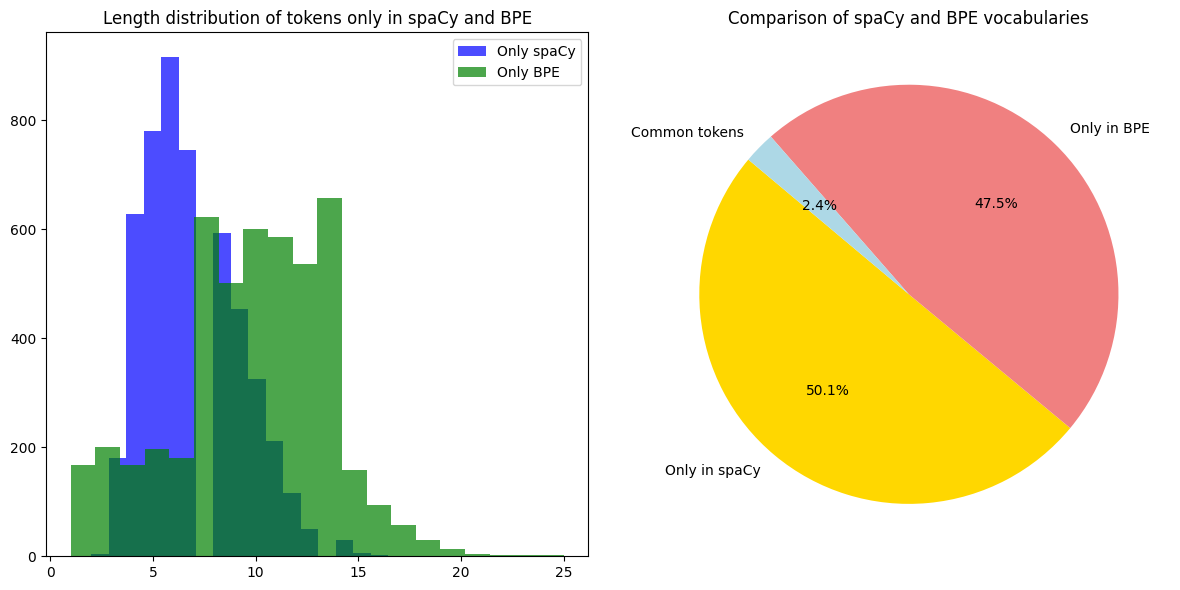

In [30]:
plt.figure(figsize=(12, 6))

# building histograms for word frequency
plt.subplot(1, 2, 1)
plt.hist([len(token) for token in only_spacy], bins=20, alpha=0.7, label='Only spaCy', color='b')
plt.hist([len(token) for token in only_bpe], bins=20, alpha=0.7, label='Only BPE', color='g')
plt.title("Length distribution of tokens only in spaCy and BPE")
plt.legend()

# construction of a circular diagram for the distribution of tokenes
plt.subplot(1, 2, 2)
labels = ['Only in spaCy', 'Only in BPE', 'Common tokens']
sizes = [len(only_spacy), len(only_bpe), len(common_tokens)]
colors = ['gold', 'lightcoral', 'lightblue']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Comparison of spaCy and BPE vocabularies")

plt.tight_layout()
plt.show()